# Analisis Uji Hipotesis
**Member:** Daffa Alfaridzi (Hypothesis Analyst)

| Task           | AI Model Usage | Justification                                                    |
| :---           | :---           | :---                                                             |
| Code Structure | High           | Generating statistical functions and template structure.         |
| Interpretation | None           | Manual analysis written by the researcher based on test results. |

In [19]:
import sys
import os
import pandas as pd
import numpy as np

sys.path.append(os.path.abspath(".."))
from src.hypothesis import z_test_one_sample

In [18]:
df = pd.read_csv('../data/clean/dataset_final.csv')
df['created_at'] = pd.to_datetime(df['created_at'])
df_bugs = df[df['is_bug'] == 1].copy()
bugs_per_minggu = df_bugs.resample('W', on='created_at').size().values

# Parameter
x_bar = np.mean(bugs_per_minggu)
sigma = np.std(bugs_per_minggu, ddof=1)
n = len(bugs_per_minggu)
mu0_asumsi = 7.4808 # Hasil Lambda dari Role B

# Uji Hipotesis
hasil = z_test_one_sample(x_bar, mu0_asumsi, sigma, n)
print(hasil)

{'z_stat': np.float64(-0.0001), 'p_value': np.float64(0.9999), 'decision': 'Fail to reject H₀'}


# Interpretasi Hasil
Berdasarkan hasil uji Z-statistik di atas:
- **Z-Statistic:** -0.0001
- **P-Value:** 0.9999
- **Keputusan:** Fail to reject H₀

*Analisis: Karena p-value (0.9999) > 0.05, maka dapat disimpulkan bahwa rata-rata penyelesaian bug mingguan tidak berbeda secara signifikan terhadap nilai asumsi 7.4808.*

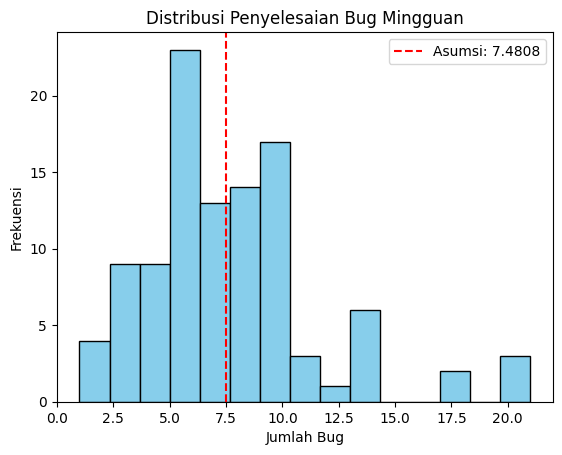

In [20]:
import matplotlib.pyplot as plt

plt.hist(bugs_per_minggu, bins=15, color='skyblue', edgecolor='black')
plt.axvline(x=mu0_asumsi, color='red', linestyle='--', label=f'Asumsi: {mu0_asumsi}')
plt.title('Distribusi Penyelesaian Bug Mingguan')
plt.xlabel('Jumlah Bug')
plt.ylabel('Frekuensi')
plt.legend()
plt.show()

**Summary & Terusan untuk Member E:**
Analisis hipotesis telah mengonfirmasi perilaku bug mingguan. Temuan ini diteruskan kepada Member E (Computation Analyst) sebagai dasar pemodelan komputasi.